In [1]:
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import os

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)



In [2]:
os.listdir("../input/osic-pulmonary-fibrosis-progression")



['train.csv',
 'sample_submission.csv',
 'test',
 'sample_submission.csv.zip',
 'test.csv',
 'test.csv.zip',
 'train.csv.zip',
 'osic-pulmonary-fibrosis-progression',
 'train.zip',
 'test.zip',
 'description.md',
 'train']

In [3]:
train = pd.read_csv("../input/osic-pulmonary-fibrosis-progression/train.csv")
test = pd.read_csv("../input/osic-pulmonary-fibrosis-progression/test.csv")



In [4]:
train.head()



,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00133637202223847701934,-2,3195,92.856312,83,Male,Never smoked
1,ID00133637202223847701934,2,3203,93.088817,83,Male,Never smoked
2,ID00133637202223847701934,4,3097,90.008138,83,Male,Never smoked
3,ID00133637202223847701934,6,3171,92.158800,83,Male,Never smoked
4,ID00133637202223847701934,8,3115,90.531272,83,Male,Never smoked


In [5]:
test.head()



,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00014637202177757139317,0,3807,90.076661,56,Male,Ex-smoker
1,ID00019637202178323708467,13,2100,92.858722,83,Female,Ex-smoker
2,ID00047637202184938901501,2,3313,89.929425,68,Male,Ex-smoker
3,ID00082637202201836229724,19,2918,99.794802,49,Female,Currently smokes
4,ID00126637202218610655908,18,2375,59.375000,78,Male,Ex-smoker


In [6]:
submission = pd.read_csv(
    "../input/osic-pulmonary-fibrosis-progression/sample_submission.csv"
)



In [7]:
submission.head()



,Patient_Week,FVC,Confidence
0,ID00126637202218610655908_-3,2000,100
1,ID00126637202218610655908_-2,2000,100
2,ID00126637202218610655908_-1,2000,100
3,ID00126637202218610655908_0,2000,100
4,ID00126637202218610655908_1,2000,100


In [8]:
print(f"Train info {train.shape}")
print(f"test info {test.shape}")
print(f"submission info {submission.shape}")



Train info (1394, 7)
test info (18, 7)
submission info (1908, 3)


In [9]:
import pydicom
import matplotlib.pyplot as plt
import seaborn as sns



In [10]:
print(f"Total Patient Id {train['Patient'].count()}")
print(f"NUmber of Unique Id {train['Patient'].value_counts().shape[0]}")



Total Patient Id 1394
NUmber of Unique Id 158


<Axes: xlabel='SmokingStatus'>

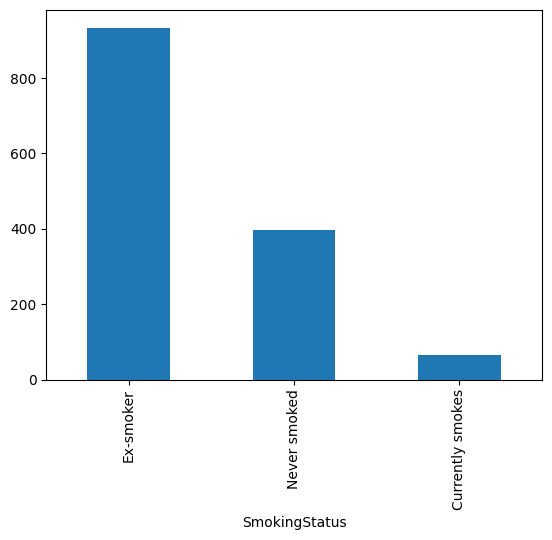

In [11]:
train["SmokingStatus"].value_counts().plot(kind="bar")



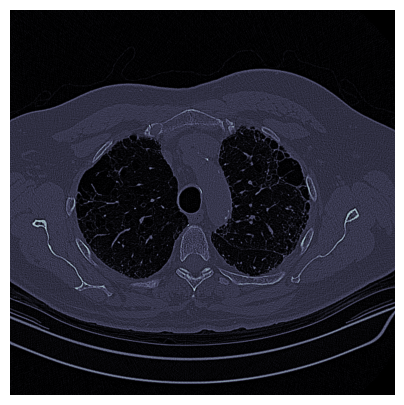

In [12]:
img = "../input/osic-pulmonary-fibrosis-progression/train/ID00009637202177434476278/100.dcm"
if os.path.exists(img):
    ds = pydicom.dcmread(img)
    plt.figure(figsize=(5, 5))
    plt.imshow(ds.pixel_array, cmap=plt.cm.bone)
    plt.axis("off")



In [13]:
import random

random.seed(RANDOM_SEED)


def get_random(smokes):
    smoke_pat = train[train["SmokingStatus"] == smokes]
    patientz = [i for i in smoke_pat["Patient"]]  # patient id list
    if len(patientz) == 0:
        print(f"No patients found for SmokingStatus={smokes}")
        return
    r_st = random.choice(patientz)  # random choice
    print(r_st)
    image_dir = (
        f"../input/osic-pulmonary-fibrosis-progression/train/{r_st}"  # image directory
    )
    if not os.path.isdir(image_dir):
        print(f"Missing image dir: {image_dir}")
        return
    image_list = os.listdir(image_dir)  # list of images
    c = []
    for t in image_list:
        first, exts = os.path.splitext(t)  # split text
        try:
            first = int(first)
            c.append(first)
        except Exception:
            continue
    d = [num for num in range(1, 31)]  # num from 1 to 30
    gh = []
    for x in c:
        if x in d:
            gh.append(x)  # if number is in list then append
    fig = plt.figure(figsize=(10, 10))  # figure
    columns = 5
    row = 6
    for ab in sorted(gh):
        files = image_dir + "/" + str(ab) + ".dcm"  # file directory
        if not os.path.exists(files):
            continue
        ds = pydicom.dcmread(files)  # read dcm file
        fig.add_subplot(row, columns, ab)  # add plot
        plt.imshow(ds.pixel_array, cmap=plt.cm.bone)  # show images
        plt.axis("off")
    plt.suptitle(smokes)  # title




ID00138637202231603868088


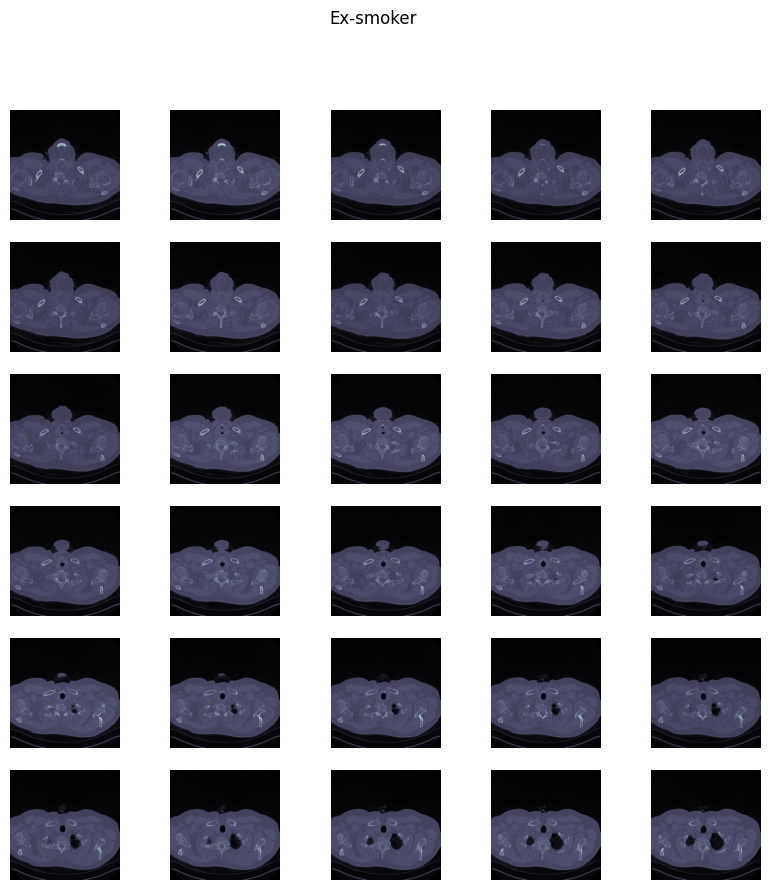

In [14]:
get_random("Ex-smoker")



In [15]:
# Change (score-relevant): keep submission rows separate from clinical feature engineering.
# We still use the same sample_submission template, but we avoid letting its dummy FVC values
# affect "First_FVC" / baseline features used by the model.
submission["Patient"] = submission["Patient_Week"].apply(lambda x: x.split("_")[0])
submission["Weeks"] = submission["Patient_Week"].apply(lambda x: int(x.split("_")[1]))

submission = submission[["Patient", "Weeks", "Confidence", "Patient_Week"]]
submission = submission.merge(test.drop("Weeks", axis=1), on="Patient", how="left")



In [16]:
submission.tail()



,Patient,Weeks,Confidence,Patient_Week,FVC,Percent,Age,Sex,SmokingStatus
1903,ID00047637202184938901501,98,100,ID00047637202184938901501_98,3313,89.929425,68,Male,Ex-smoker
1904,ID00047637202184938901501,99,100,ID00047637202184938901501_99,3313,89.929425,68,Male,Ex-smoker
1905,ID00047637202184938901501,100,100,ID00047637202184938901501_100,3313,89.929425,68,Male,Ex-smoker
1906,ID00047637202184938901501,101,100,ID00047637202184938901501_101,3313,89.929425,68,Male,Ex-smoker
1907,ID00047637202184938901501,102,100,ID00047637202184938901501_102,3313,89.929425,68,Male,Ex-smoker


In [17]:
submission.shape



(1908, 9)

In [18]:
train.head()



,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00133637202223847701934,-2,3195,92.856312,83,Male,Never smoked
1,ID00133637202223847701934,2,3203,93.088817,83,Male,Never smoked
2,ID00133637202223847701934,4,3097,90.008138,83,Male,Never smoked
3,ID00133637202223847701934,6,3171,92.158800,83,Male,Never smoked
4,ID00133637202223847701934,8,3115,90.531272,83,Male,Never smoked


In [19]:
test



,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00014637202177757139317,0,3807,90.076661,56,Male,Ex-smoker
1,ID00019637202178323708467,13,2100,92.858722,83,Female,Ex-smoker
2,ID00047637202184938901501,2,3313,89.929425,68,Male,Ex-smoker
3,ID00082637202201836229724,19,2918,99.794802,49,Female,Currently smokes
4,ID00126637202218610655908,18,2375,59.375000,78,Male,Ex-smoker
5,ID00127637202219096738943,44,1677,65.855095,55,Female,Ex-smoker
6,ID00135637202224630271439,31,3808,106.096066,65,Male,Never smoked
7,ID00213637202257692916109,6,3035,83.562775,70,Male,Currently smokes
8,ID00219637202258203123958,0,6399,153.012912,71,Male,Ex-smoker
9,ID00225637202259339837603,13,1583,80.172195,77,Female,Never smoked


<Axes: >

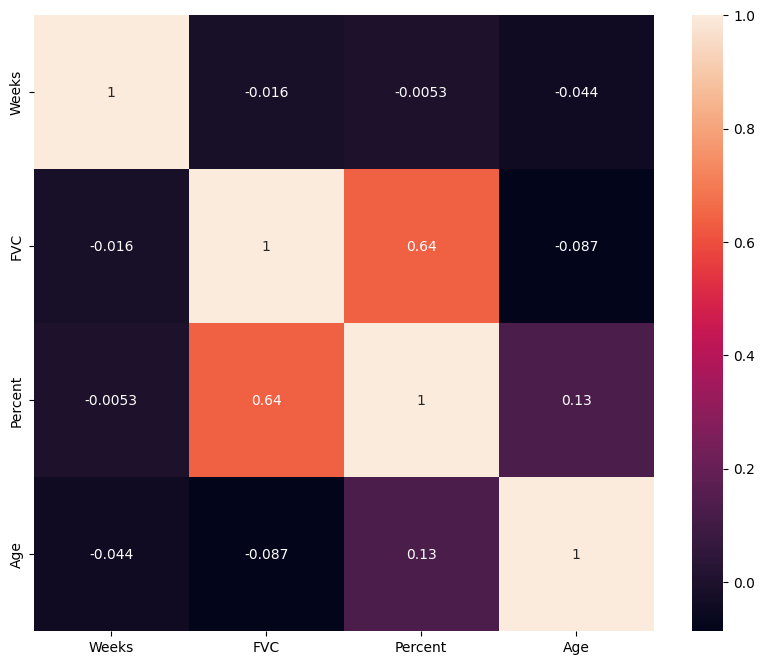

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(train.select_dtypes(include=[np.number]).corr(), annot=True)



In [21]:
test



,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00014637202177757139317,0,3807,90.076661,56,Male,Ex-smoker
1,ID00019637202178323708467,13,2100,92.858722,83,Female,Ex-smoker
2,ID00047637202184938901501,2,3313,89.929425,68,Male,Ex-smoker
3,ID00082637202201836229724,19,2918,99.794802,49,Female,Currently smokes
4,ID00126637202218610655908,18,2375,59.375000,78,Male,Ex-smoker
5,ID00127637202219096738943,44,1677,65.855095,55,Female,Ex-smoker
6,ID00135637202224630271439,31,3808,106.096066,65,Male,Never smoked
7,ID00213637202257692916109,6,3035,83.562775,70,Male,Currently smokes
8,ID00219637202258203123958,0,6399,153.012912,71,Male,Ex-smoker
9,ID00225637202259339837603,13,1583,80.172195,77,Female,Never smoked


In [22]:
submission["Patient"].unique()



array(['ID00126637202218610655908', 'ID00364637202296074419422',
       'ID00135637202224630271439', 'ID00127637202219096738943',
       'ID00294637202279614924243', 'ID00233637202260580149633',
       'ID00019637202178323708467', 'ID00383637202300493233675',
       'ID00317637202283194142136', 'ID00213637202257692916109',
       'ID00339637202287377736231', 'ID00344637202287684217717',
       'ID00014637202177757139317', 'ID00225637202259339837603',
       'ID00407637202308788732304', 'ID00219637202258203123958',
       'ID00082637202201836229724', 'ID00047637202184938901501'],
      dtype=object)

In [23]:
train.shape



(1394, 7)

In [24]:
train["Dataset"] = "train"
test["Dataset"] = "test"
submission["Dataset"] = "submission"



In [25]:
# Change (score-relevant): compute patient-level baseline features from real data only (train+test),
# then merge into submission. This prevents leakage of sample-submission "FVC" into baselines.
base = pd.concat([train, test], axis=0, ignore_index=True)

# Patient's first observed week in real data (train: min across all history; test: its baseline week)
first_week = base.groupby("Patient")["Weeks"].min().rename("First_week").reset_index()

# Patient's FVC at that first week (for train: actual at earliest week; for test: baseline FVC)
first_fvc_rows = base.merge(first_week, on="Patient", how="left")
first_fvc_rows = first_fvc_rows[first_fvc_rows["Weeks"] == first_fvc_rows["First_week"]]
first_fvc = (
    first_fvc_rows.groupby("Patient")["FVC"].first().rename("First_FVC").reset_index()
)

patient_baseline = first_week.merge(first_fvc, on="Patient", how="left")

# Now build the combined dataset but do NOT recompute baselines from it; only merge them in.
dataset = pd.concat([train, test, submission], axis=0, ignore_index=True)
dataset = dataset.merge(patient_baseline, on="Patient", how="left")



In [26]:
dataset.head()



/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus,Dataset,Confidence,Patient_Week,First_week,First_FVC
0,ID00133637202223847701934,-2,3195,92.856312,83,Male,Never smoked,train,NaN,NaN,-2,3195
1,ID00133637202223847701934,2,3203,93.088817,83,Male,Never smoked,train,NaN,NaN,-2,3195
2,ID00133637202223847701934,4,3097,90.008138,83,Male,Never smoked,train,NaN,NaN,-2,3195
3,ID00133637202223847701934,6,3171,92.158800,83,Male,Never smoked,train,NaN,NaN,-2,3195
4,ID00133637202223847701934,8,3115,90.531272,83,Male,Never smoked,train,NaN,NaN,-2,3195


In [27]:
dataset["Weeks"] = dataset["Weeks"].astype("int64")



In [28]:
dataset.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3320 entries, 0 to 3319
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Patient        3320 non-null   object 
 1   Weeks          3320 non-null   int64  
 2   FVC            3320 non-null   int64  
 3   Percent        3320 non-null   float64
 4   Age            3320 non-null   int64  
 5   Sex            3320 non-null   object 
 6   SmokingStatus  3320 non-null   object 
 7   Dataset        3320 non-null   object 
 8   Confidence     1908 non-null   float64
 9   Patient_Week   1908 non-null   object 
 10  First_week     3320 non-null   int64  
 11  First_FVC      3320 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 311.4+ KB


In [29]:
# Keep your existing engineered feature "Week_diff" semantics.
dataset["Week_diff"] = dataset["Weeks"] - dataset["First_week"]

dataset = pd.concat(
    [dataset, pd.get_dummies(dataset.Sex), pd.get_dummies(dataset.SmokingStatus)],
    axis=1,
)
dataset = dataset.drop(columns=["Sex", "SmokingStatus"])



In [30]:
dataset.tail()



,Patient,Weeks,FVC,Percent,Age,Dataset,Confidence,Patient_Week,First_week,First_FVC,Week_diff,Female,Male,Currently smokes,Ex-smoker,Never smoked
3315,ID00047637202184938901501,98,3313,89.929425,68,submission,100.0,ID00047637202184938901501_98,2,3313,96,False,True,False,True,False
3316,ID00047637202184938901501,99,3313,89.929425,68,submission,100.0,ID00047637202184938901501_99,2,3313,97,False,True,False,True,False
3317,ID00047637202184938901501,100,3313,89.929425,68,submission,100.0,ID00047637202184938901501_100,2,3313,98,False,True,False,True,False
3318,ID00047637202184938901501,101,3313,89.929425,68,submission,100.0,ID00047637202184938901501_101,2,3313,99,False,True,False,True,False
3319,ID00047637202184938901501,102,3313,89.929425,68,submission,100.0,ID00047637202184938901501_102,2,3313,100,False,True,False,True,False


In [31]:
dataset.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3320 entries, 0 to 3319
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient           3320 non-null   object 
 1   Weeks             3320 non-null   int64  
 2   FVC               3320 non-null   int64  
 3   Percent           3320 non-null   float64
 4   Age               3320 non-null   int64  
 5   Dataset           3320 non-null   object 
 6   Confidence        1908 non-null   float64
 7   Patient_Week      1908 non-null   object 
 8   First_week        3320 non-null   int64  
 9   First_FVC         3320 non-null   int64  
 10  Week_diff         3320 non-null   int64  
 11  Female            3320 non-null   bool   
 12  Male              3320 non-null   bool   
 13  Currently smokes  3320 non-null   bool   
 14  Ex-smoker         3320 non-null   bool   
 15  Never smoked      3320 non-null   bool   
dtypes: bool(5), float64(2), int64(6), object(3

In [32]:
train = dataset[dataset["Dataset"] == "train"].copy()
test = dataset[dataset["Dataset"] == "test"].copy()
submission = dataset[dataset["Dataset"] == "submission"].copy()



In [33]:
from sklearn.preprocessing import StandardScaler

expected_ohe = ["Female", "Male", "Currently smokes", "Ex-smoker", "Never smoked"]
for df_ in (train, test, submission):
    for c in expected_ohe:
        if c not in df_.columns:
            df_[c] = 0

col = [
    "Weeks",
    "Percent",
    "Age",
    "First_week",
    "First_FVC",
    "Week_diff",
    "Female",
    "Male",
    "Currently smokes",
    "Ex-smoker",
    "Never smoked",
]

train_data = train[col].copy()



In [34]:
train_data.isnull().any()



Weeks               False
Percent             False
Age                 False
First_week          False
First_FVC           False
Week_diff           False
Female              False
Male                False
Currently smokes    False
Ex-smoker           False
Never smoked        False
dtype: bool

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


<Axes: >

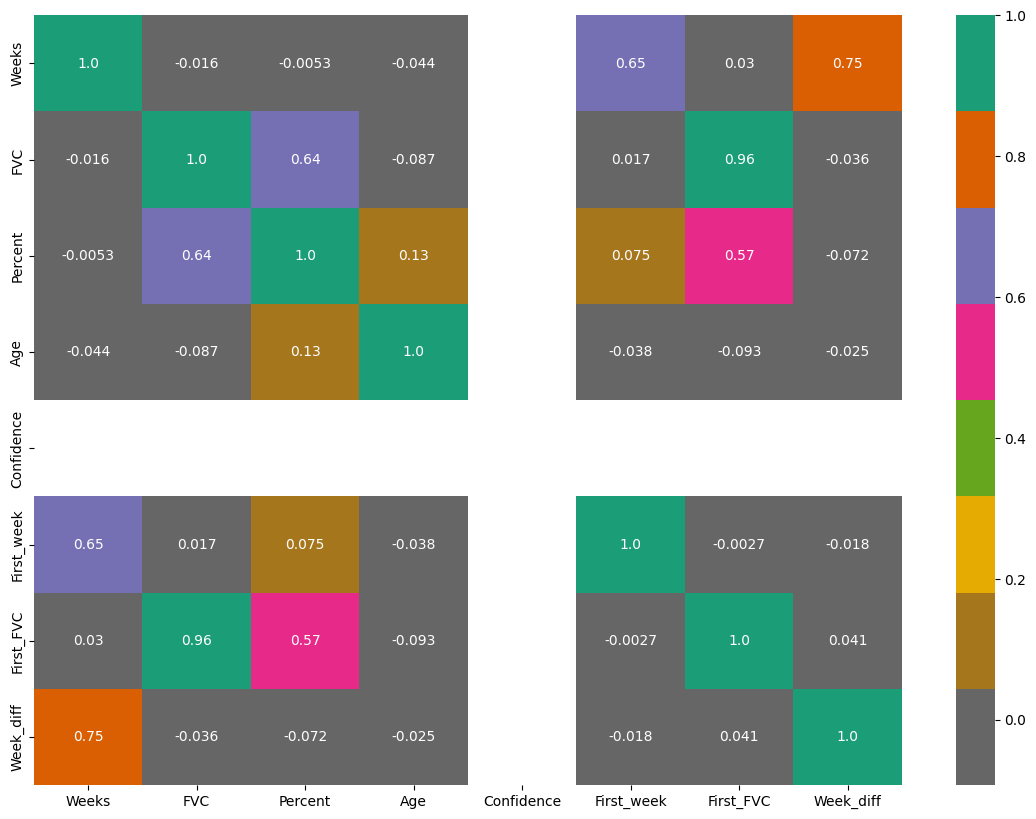

In [35]:
plt.subplots(figsize=(14, 10))
g = train.select_dtypes(include=[np.number]).corr()
sns.heatmap(g, annot=True, fmt=".2", cmap="Dark2_r")



In [36]:
g["FVC"].sort_values(ascending=False)



/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


FVC           1.000000
First_FVC     0.960744
Percent       0.637566
First_week    0.017481
Weeks        -0.016234
Week_diff    -0.036451
Age          -0.086927
Confidence         NaN
Name: FVC, dtype: float64

In [37]:
stdscale = StandardScaler()
train_data.loc[:, col] = stdscale.fit_transform(train_data[col])



/tmp/ipykernel_11/1456144197.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.45554914 -1.2824454  -1.19589353 ...  0.96790323  1.6603182
  1.6603182 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_data.loc[:, col] = stdscale.fit_transform(train_data[col])
/tmp/ipykernel_11/1456144197.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2.28540806 2.28540806 2.28540806 ... 0.10450798 0.10450798 0.10450798]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_data.loc[:, col] = stdscale.fit_transform(train_data[col])
/tmp/ipykernel_11/1456144197.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.06601168 -1.06601168 -1.06601168 ...  0.04691597  0.04691597
  0.04691597]' h

In [38]:
train_data[col].head()



,Weeks,Percent,Age,First_week,First_FVC,Week_diff,Female,Male,Currently smokes,Ex-smoker,Never smoked
0,-1.455549,0.823317,2.285408,-1.066012,0.552553,-0.984880,-0.502465,0.502465,-0.219363,-1.424933,1.587514
1,-1.282445,0.835358,2.285408,-1.066012,0.552553,-0.757829,-0.502465,0.502465,-0.219363,-1.424933,1.587514
2,-1.195894,0.675807,2.285408,-1.066012,0.552553,-0.644303,-0.502465,0.502465,-0.219363,-1.424933,1.587514
3,-1.109342,0.787192,2.285408,-1.066012,0.552553,-0.530778,-0.502465,0.502465,-0.219363,-1.424933,1.587514
4,-1.022790,0.702900,2.285408,-1.066012,0.552553,-0.417252,-0.502465,0.502465,-0.219363,-1.424933,1.587514


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR



In [40]:
model_params = {
    "svr": {
        "model": SVR(),
        "params": {"C": [1, 10, 20], "kernel": ["linear", "poly", "rbf", "sigmoid"]},
    },
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {"n_estimators": [100, 200]},
    },
    "LR": {"model": LinearRegression(), "params": {}},
}



In [41]:
from sklearn.model_selection import GridSearchCV

scores = []
for model_name, param in model_params.items():
    cv_folds = 5  # keep as-is from your current solution
    clf = GridSearchCV(
        param["model"], param["params"], cv=cv_folds, return_train_score=False
    )
    clf.fit(train_data[col], train["FVC"])
    scores.append(
        {
            "model": model_name,
            "best_score": clf.best_score_,
            "best_params": clf.best_params_,
        }
    )

df = pd.DataFrame(scores, columns=["model", "best_score", "best_params"])
df



,model,best_score,best_params
0,svr,0.943684,"{'C': 10, 'kernel': 'linear'}"
1,RandomForest,0.928147,{'n_estimators': 200}
2,LR,0.943574,{}


In [42]:
model = LinearRegression()
model.fit(train_data[col], train["FVC"])



LinearRegression()

In [43]:
pred = model.predict(train_data[col])
pred[:10]



array([3163.27889102, 3156.87820678, 3119.24181709, 3137.95532342,
       3115.97168263, 3101.70972777, 3048.62794509, 3029.14773356,
       2987.8922477 , 1455.31621629])

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = mean_squared_error(train["FVC"], pred, squared=False)
print(rmse)

mae = mean_absolute_error(train["FVC"], pred)
print(mae)



177.89668142483367
133.2131362407699


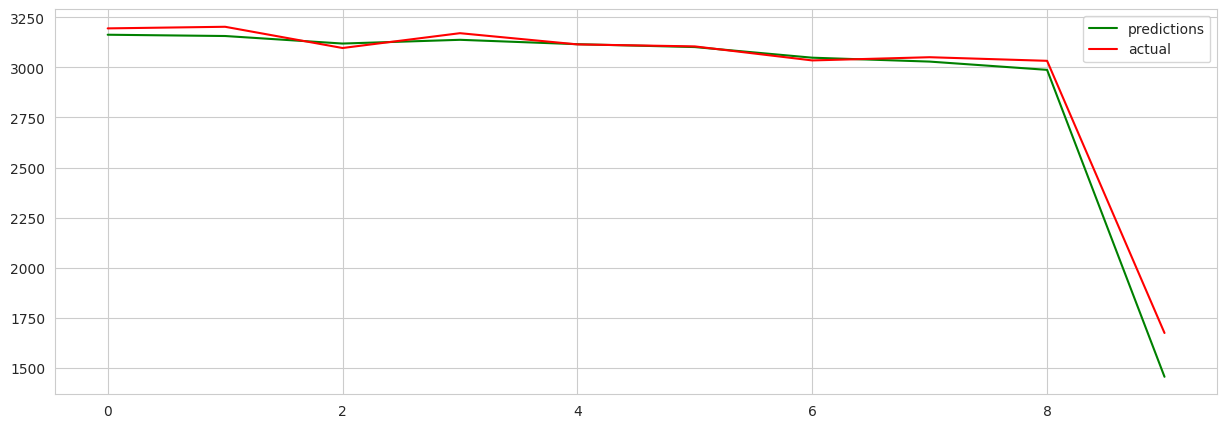

In [45]:
a = list(train["FVC"])
b = list(pred)

sns.set_style("whitegrid")
f, ax = plt.subplots(figsize=(15, 5))
plt.plot(b[:10], c="green", label="predictions")
plt.plot(a[:10], c="red", label="actual")
plt.legend()



In [46]:
submission[col].isnull().any()



Weeks               False
Percent             False
Age                 False
First_week          False
First_FVC           False
Week_diff           False
Female              False
Male                False
Currently smokes    False
Ex-smoker           False
Never smoked        False
dtype: bool

In [47]:
sub_data = submission[col].copy()
sub_data.loc[:, col] = stdscale.transform(sub_data[col])



/tmp/ipykernel_11/2868162071.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.49882507 -1.45554914 -1.4122732  ...  2.95859625  3.00187219
  3.04514812]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub_data.loc[:, col] = stdscale.transform(sub_data[col])
/tmp/ipykernel_11/2868162071.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.55844137 1.55844137 1.55844137 ... 0.10450798 0.10450798 0.10450798]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub_data.loc[:, col] = stdscale.transform(sub_data[col])
/tmp/ipykernel_11/2868162071.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.24331497  0.24331497  0.24331497 ... -0.80414635 -0.80414635
 -0.80414635]' has dtype incomp

In [48]:
pred_2 = model.predict(sub_data[col])



In [49]:
pred_2[:10]



array([2285.60338141, 2283.3771004 , 2281.15081938, 2278.92453837,
       2276.69825735, 2274.47197633, 2272.24569532, 2270.0194143 ,
       2267.79313329, 2265.56685227])

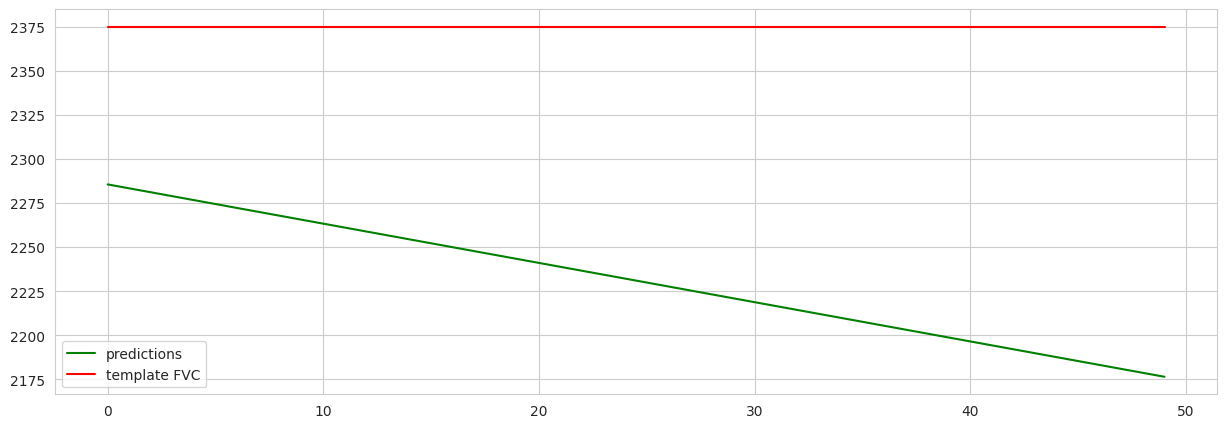

In [50]:
a = list(submission["FVC"])  # from sample_submission template (not true labels)
b = list(pred_2)

sns.set_style("whitegrid")
f, ax = plt.subplots(figsize=(15, 5))
plt.plot(b[:50], c="green", label="predictions")
plt.plot(a[:50], c="red", label="template FVC")
plt.legend()



In [51]:
submission["FVC"].head()



1412    2375
1413    2375
1414    2375
1415    2375
1416    2375
Name: FVC, dtype: int64

In [52]:
test.head()



/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Patient,Weeks,FVC,Percent,Age,Dataset,Confidence,Patient_Week,First_week,First_FVC,Week_diff,Female,Male,Currently smokes,Ex-smoker,Never smoked
1394,ID00014637202177757139317,0,3807,90.076661,56,test,NaN,NaN,0,3807,0,False,True,False,True,False
1395,ID00019637202178323708467,13,2100,92.858722,83,test,NaN,NaN,13,2100,0,True,False,False,True,False
1396,ID00047637202184938901501,2,3313,89.929425,68,test,NaN,NaN,2,3313,0,False,True,False,True,False
1397,ID00082637202201836229724,19,2918,99.794802,49,test,NaN,NaN,19,2918,0,True,False,True,False,False
1398,ID00126637202218610655908,18,2375,59.375000,78,test,NaN,NaN,18,2375,0,False,True,False,True,False


In [53]:
submission.head()



,Patient,Weeks,FVC,Percent,Age,Dataset,Confidence,Patient_Week,First_week,First_FVC,Week_diff,Female,Male,Currently smokes,Ex-smoker,Never smoked
1412,ID00126637202218610655908,-3,2375,59.375,78,submission,100.0,ID00126637202218610655908_-3,18,2375,-21,False,True,False,True,False
1413,ID00126637202218610655908,-2,2375,59.375,78,submission,100.0,ID00126637202218610655908_-2,18,2375,-20,False,True,False,True,False
1414,ID00126637202218610655908,-1,2375,59.375,78,submission,100.0,ID00126637202218610655908_-1,18,2375,-19,False,True,False,True,False
1415,ID00126637202218610655908,0,2375,59.375,78,submission,100.0,ID00126637202218610655908_0,18,2375,-18,False,True,False,True,False
1416,ID00126637202218610655908,1,2375,59.375,78,submission,100.0,ID00126637202218610655908_1,18,2375,-17,False,True,False,True,False


In [54]:
train.head()



/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Patient,Weeks,FVC,Percent,Age,Dataset,Confidence,Patient_Week,First_week,First_FVC,Week_diff,Female,Male,Currently smokes,Ex-smoker,Never smoked
0,ID00133637202223847701934,-2,3195,92.856312,83,train,NaN,NaN,-2,3195,0,False,True,False,False,True
1,ID00133637202223847701934,2,3203,93.088817,83,train,NaN,NaN,-2,3195,4,False,True,False,False,True
2,ID00133637202223847701934,4,3097,90.008138,83,train,NaN,NaN,-2,3195,6,False,True,False,False,True
3,ID00133637202223847701934,6,3171,92.158800,83,train,NaN,NaN,-2,3195,8,False,True,False,False,True
4,ID00133637202223847701934,8,3115,90.531272,83,train,NaN,NaN,-2,3195,10,False,True,False,False,True


In [55]:
# Change (score-relevant): compute a stable Confidence using training residual dispersion per patient.
# This aligns better with the competition's likelihood metric than using baseline error (often near 0 -> clipped to 70).
submission["FVC_1"] = pred_2

train_with_pred = train.copy()
train_with_pred["_pred"] = pred
train_with_pred["_abs_err"] = (train_with_pred["FVC"] - train_with_pred["_pred"]).abs()

# Per-patient median absolute error on training (robust and tends to improve calibration)
pat_sigma = train_with_pred.groupby("Patient")["_abs_err"].median()

# Global fallback (for patients not present in training, i.e., test patients)
global_sigma = float(train_with_pred["_abs_err"].median())

# Map to submission patients, clip to the competition's effective minimum 70
submission["Confidence"] = (
    submission["Patient"].map(pat_sigma).fillna(global_sigma).astype(float)
)
submission["Confidence"] = submission["Confidence"].clip(lower=70.0)



In [56]:
new = submission[["Patient_Week", "FVC_1", "Confidence"]].copy()
new.rename(columns={"FVC_1": "FVC"}, inplace=True)



In [57]:
new.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", new.shape)
print(new.head())

Wrote submission.csv with shape: (1908, 3)
                      Patient_Week          FVC  Confidence
1412  ID00126637202218610655908_-3  2285.603381  104.175021
1413  ID00126637202218610655908_-2  2283.377100  104.175021
1414  ID00126637202218610655908_-1  2281.150819  104.175021
1415   ID00126637202218610655908_0  2278.924538  104.175021
1416   ID00126637202218610655908_1  2276.698257  104.175021
